In [3]:
import numpy as np
import re
import json
import transforms3d.euler as euler
from datetime import datetime

def parse_sensor_log(sensor_log_file):
    """Parse sensor log to extract timestamps and quaternions"""
    sensor_pattern = r'\[INFO\] \[(\d+\.\d+)\] \[turtle_sensors_node\]: (.+)'
    
    timestamps = []
    quaternions = []
    
    with open(sensor_log_file, 'r') as f:
        for line in f:
            match = re.search(sensor_pattern, line)
            if match:
                timestamp = float(match.group(1))
                data_str = match.group(2)
                
                # Parse JSON data
                if data_str.strip().startswith('{') and data_str.strip().endswith('}'):
                    try:
                        sensor_json = json.loads(data_str)
                        quat = sensor_json.get('Quat', None)
                        if quat and len(quat) == 4:
                            timestamps.append(timestamp)
                            quaternions.append(quat)
                    except json.JSONDecodeError:
                        continue
    
    return np.array(timestamps), np.array(quaternions)

def parse_heading_log(heading_log_file):
    """Parse heading log to extract headings"""
    heading_pattern = r'heading: ([-\d.]+)'
    
    headings = []
    
    with open(heading_log_file, 'r') as f:
        for line in f:
            match = re.search(heading_pattern, line)
            if match:
                heading = float(match.group(1))
                headings.append(heading)
    
    return np.array(headings)

def quaternion_to_heading(quat, euler_convention='szyx'):
    """Convert quaternion to heading (yaw angle)"""
    q_eul = euler.quat2euler(quat, euler_convention)
    heading = q_eul[0]  # yaw is first element
    return heading

def match_headings_to_timestamps(sensor_log_file, heading_log_file, euler_convention='szyx', tolerance=1e-4):
    """
    Match headings from log to sensor timestamps by comparing quaternion-derived headings
    
    Args:
        sensor_log_file: Path to sensor log file
        heading_log_file: Path to heading log file  
        euler_convention: Euler angle convention (default 'szyx')
        tolerance: Tolerance for heading matching (radians)
    
    Returns:
        matched_timestamps: Array of timestamps corresponding to each heading
        unmatched_indices: Indices of headings that couldn't be matched
    """
    
    # Parse both logs
    print("Parsing sensor log...")
    timestamps, quaternions = parse_sensor_log(sensor_log_file)
    print(f"Found {len(timestamps)} sensor readings with quaternions")
    time_elapsed = timestamps - timestamps[0]
    print(f"time elapsed: {time_elapsed[-1]}")
    print("Parsing heading log...")
    headings = parse_heading_log(heading_log_file)
    print(f"Found {len(headings)} heading readings")
    
    # Convert all quaternions to headings
    print("Converting quaternions to headings...")
    sensor_headings = np.array([quaternion_to_heading(q, euler_convention) for q in quaternions])
    print(f"sensor headings: {sensor_headings[0:5]}")
    print(f"logged headings: {headings[0:5]}")
    # Match each logged heading to closest sensor heading
    matched_timestamps = []
    unmatched_indices = []
    print(f"\nSensor heading stats:")
    print(f"  Range: [{sensor_headings.min():.3f}, {sensor_headings.max():.3f}]")
    print(f"  Mean: {sensor_headings.mean():.3f}")
    
    print(f"\nLogged heading stats:")
    print(f"  Range: [{headings.min():.3f}, {headings.max():.3f}]")
    print(f"  Mean: {headings.mean():.3f}")

    match_diffs = []
    print("Matching headings...")
    sensor_idx = 0  # Start searching from here for efficiency
    for i, target_heading in enumerate(headings):
        # Search forward from last match position
        best_diff = float('inf')
        best_idx = -1
        
        # Search within a window around current position
        search_start = max(0, sensor_idx - 500)
        search_end = min(len(sensor_headings), sensor_idx + 1000)
        
        for j in range(search_start, search_end):
            diff = abs(sensor_headings[j] - target_heading)
            if diff < best_diff:
                best_diff = diff
                best_idx = j
        
        if best_diff < tolerance:
            matched_timestamps.append(timestamps[best_idx])
            match_diffs.append(best_diff)
            sensor_idx = best_idx + 1  # Move forward for next search
            # ADD THIS: Warn about backwards matches
            if len(matched_timestamps) > 1 and matched_timestamps[-1] < matched_timestamps[-2]:
                print(f"⚠️  Index {i}: Backwards match! {matched_timestamps[-2]:.3f} -> {matched_timestamps[-1]:.3f}")
                print(f"    Target heading: {target_heading:.6f}, Matched heading: {sensor_headings[best_idx]:.6f}")
        else:
            # No good match found
            matched_timestamps.append(np.nan)
            unmatched_indices.append(i)
            print(f"Warning: Could not match heading at index {i} (value: {target_heading:.6f})")
    # ADD THIS: Report match quality
    if match_diffs:
        print(f"\nMatch quality:")
        print(f"  Median diff: {np.median(match_diffs):.6f} rad")
        print(f"  Max diff: {np.max(match_diffs):.6f} rad")    
    matched_timestamps = np.array(matched_timestamps)
    
    # Convert to elapsed time from start
    if len(matched_timestamps) > 0:
        valid_timestamps = matched_timestamps[~np.isnan(matched_timestamps)]
        if len(valid_timestamps) > 0:
            start_time = valid_timestamps[0]
            matched_timestamps = matched_timestamps - start_time
    
    print(f"\nMatching complete:")
    print(f"  Matched: {len(headings) - len(unmatched_indices)}/{len(headings)}")
    print(f"  Unmatched: {len(unmatched_indices)}")
    
    return matched_timestamps, unmatched_indices

def save_timestamps(timestamps, output_file):
    """Save timestamps to file"""
    np.savetxt(output_file, timestamps, fmt='%.6f', header='Elapsed_Time_Seconds')
    print(f"Saved timestamps to {output_file}")


In [4]:
# File paths
sensor_log = "TurtleSensors.log"  # Replace with your sensor log path
heading_log = "untethered_planning_node.log"  # Replace with your heading log path
output_file = "matched_timestamps_other.txt"

# Match headings to timestamps
timestamps, unmatched = match_headings_to_timestamps(
    sensor_log, 
    heading_log,
    euler_convention='szyx',
    tolerance=0.01
)

# Save results
save_timestamps(timestamps, output_file)# Print statistics
print(f"\nTimestamp range: {np.nanmin(timestamps):.2f}s to {np.nanmax(timestamps):.2f}s")
print(f"Duration: {np.nanmax(timestamps) - np.nanmin(timestamps):.2f}s")

Parsing sensor log...
Found 21713 sensor readings with quaternions
time elapsed: 426.3431386947632
Parsing heading log...
Found 8422 heading readings
Converting quaternions to headings...
sensor headings: [-0.00000000e+00 -0.00000000e+00  3.99998800e-06 -1.98798943e-03
 -3.97596712e-03]
logged headings: [-0.         -0.01395722 -0.01195738 -0.00993544 -0.00991579]

Sensor heading stats:
  Range: [-3.142, 3.142]
  Mean: 0.279

Logged heading stats:
  Range: [-3.141, 3.142]
  Mean: 0.279
Matching headings...
⚠️  Index 6208: Backwards match! 1744787946.772 -> 1744787945.615
    Target heading: 0.382012, Matched heading: 0.382012
⚠️  Index 6759: Backwards match! 1744787988.121 -> 1744787988.033
    Target heading: -1.682498, Matched heading: -1.683698
⚠️  Index 6760: Backwards match! 1744787988.033 -> 1744787987.869
    Target heading: -1.657582, Matched heading: -1.657736
⚠️  Index 6761: Backwards match! 1744787987.869 -> 1744787987.766
    Target heading: -1.636050, Matched heading: -1.6

In [5]:
def match_headings_to_timestamps_v2(sensor_log_file, heading_log_file, euler_convention='szyx', tolerance=0.01):
    """Match headings without enforcing forward-only search"""
    
    timestamps, quaternions = parse_sensor_log(sensor_log_file)
    headings = parse_heading_log(heading_log_file)
    
    sensor_headings = np.array([quaternion_to_heading(q, euler_convention) for q in quaternions])
    
    print(f"Sensor time range: {timestamps[0]:.3f} to {timestamps[-1]:.3f}")
    print(f"Duration: {timestamps[-1] - timestamps[0]:.3f}s")
    
    matched_timestamps = []
    matched_indices = []
    
    # For each heading, find best match in ENTIRE sensor log (no forward constraint)
    for i, target_heading in enumerate(headings):
        # Angle difference accounting for wrap-around
        angle_diffs = np.arctan2(np.sin(sensor_headings - target_heading), 
                                  np.cos(sensor_headings - target_heading))
        diffs = np.abs(angle_diffs)
        
        best_idx = np.argmin(diffs)
        best_diff = diffs[best_idx]
        
        if best_diff < tolerance:
            matched_timestamps.append(timestamps[best_idx])
            matched_indices.append(best_idx)
        else:
            matched_timestamps.append(np.nan)
            matched_indices.append(-1)
            print(f"Warning: Could not match heading at index {i}")
    
    matched_timestamps = np.array(matched_timestamps)
    matched_indices = np.array(matched_indices)
    
    # Check monotonicity
    valid_mask = matched_indices >= 0
    valid_indices = matched_indices[valid_mask]
    non_monotonic = np.sum(np.diff(valid_indices) < 0)
    
    print(f"\nMatching stats:")
    print(f"  Total matches: {np.sum(valid_mask)}/{len(headings)}")
    print(f"  Non-monotonic transitions: {non_monotonic}")
    
    # Convert to elapsed time
    valid_timestamps = matched_timestamps[~np.isnan(matched_timestamps)]
    if len(valid_timestamps) > 0:
        start_time = timestamps[0]  # Use sensor log start, not first match!
        matched_timestamps = matched_timestamps - start_time
    
    return matched_timestamps, matched_indices

def enforce_monotonicity(timestamps, tolerance=0.1):
    """
    Post-process timestamps to enforce monotonic increasing order
    
    Args:
        timestamps: Array of timestamps (may contain NaN)
        tolerance: Maximum backwards jump to interpolate over (seconds)
    
    Returns:
        monotonic_timestamps: Timestamps with non-monotonic sections interpolated
    """
    result = timestamps.copy()
    
    for i in range(1, len(result)):
        if np.isnan(result[i]):
            continue
            
        if not np.isnan(result[i-1]) and result[i] < result[i-1]:
            backwards_jump = result[i-1] - result[i]
            
            if backwards_jump < tolerance:
                # Small jump: interpolate
                result[i] = result[i-1] + 0.001  # Small increment
                print(f"Fixed small backwards jump at index {i}: {backwards_jump:.3f}s")
            else:
                # Large jump: likely wrong match, set to NaN
                result[i] = np.nan
                print(f"Removed large backwards jump at index {i}: {backwards_jump:.3f}s")
    
    return result

In [6]:
# Match without temporal constraints
timestamps, indices = match_headings_to_timestamps_v2(
    sensor_log,
    heading_log,
    euler_convention='szyx',
    tolerance=0.01
)

# Enforce monotonicity
timestamps_clean = enforce_monotonicity(timestamps, tolerance=0.5)

# Save
save_timestamps(timestamps_clean, output_file)

Sensor time range: 1744787635.468 to 1744788061.811
Duration: 426.343s

Matching stats:
  Total matches: 8422/8422
  Non-monotonic transitions: 5
Removed large backwards jump at index 6208: 1.157s
Removed large backwards jump at index 6751: 13.673s
Removed large backwards jump at index 7229: 160.136s
Fixed small backwards jump at index 7653: 0.026s
Fixed small backwards jump at index 8017: 0.011s
Saved timestamps to matched_timestamps_other.txt


Sensor time range: 1744787635.468 to 1744788061.811
Duration: 426.343s

Matching stats:
  Total matches: 8422/8422
  Non-monotonic transitions: 5


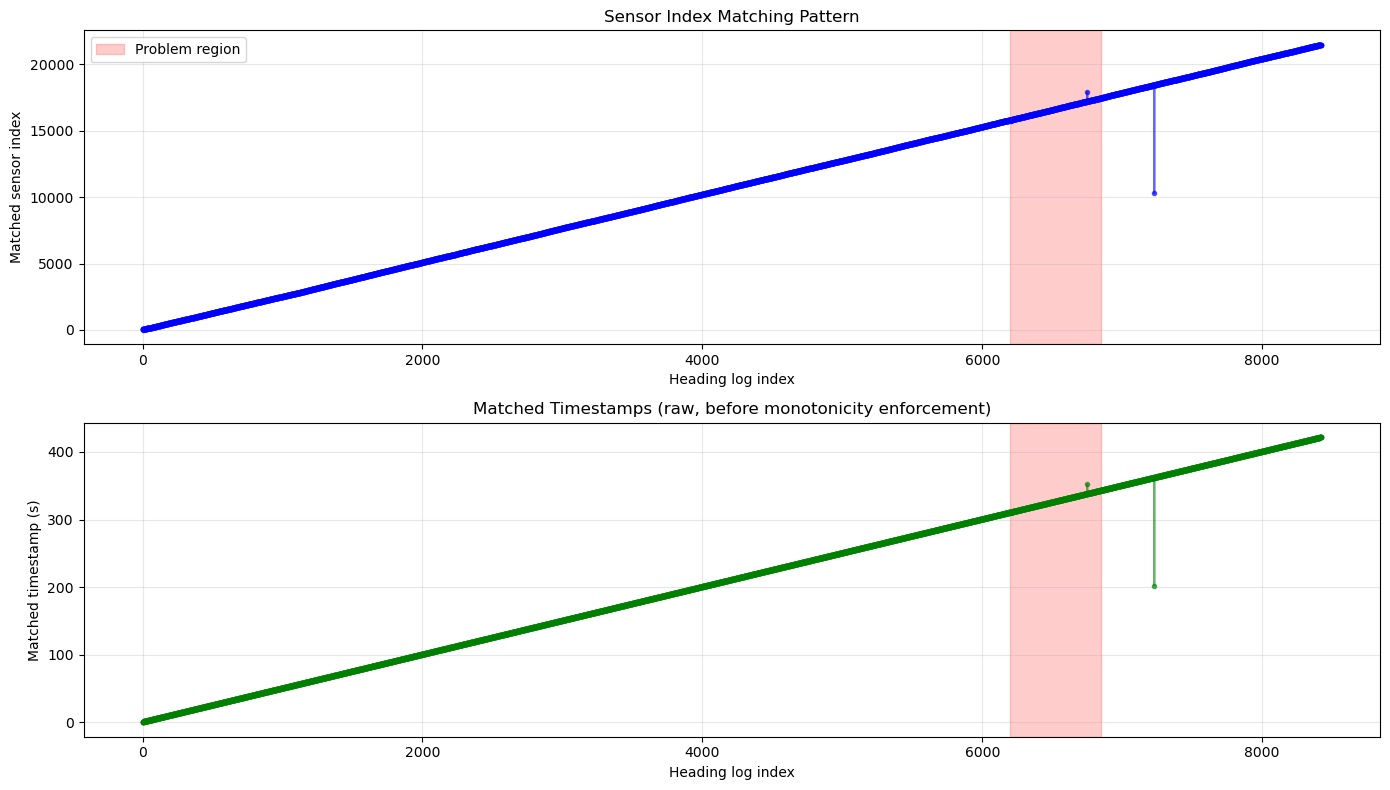


Problem region analysis (indices 6200-6850):
Heading 6200: matched to sensor index 15815, timestamp 310.965s
Heading 6201: matched to sensor index 15817, timestamp 311.003s
Heading 6202: matched to sensor index 15819, timestamp 311.060s
Heading 6203: matched to sensor index 15822, timestamp 311.120s
Heading 6204: matched to sensor index 15824, timestamp 311.149s
Heading 6205: matched to sensor index 15827, timestamp 311.221s
Heading 6206: matched to sensor index 15829, timestamp 311.261s
Heading 6207: matched to sensor index 15831, timestamp 311.304s
Heading 6208: matched to sensor index 15776, timestamp 310.147s
Heading 6209: matched to sensor index 15838, timestamp 311.422s
Heading 6210: matched to sensor index 15841, timestamp 311.473s
Heading 6211: matched to sensor index 15844, timestamp 311.517s
Heading 6212: matched to sensor index 15847, timestamp 311.557s
Heading 6213: matched to sensor index 15849, timestamp 311.603s
Heading 6214: matched to sensor index 15851, timestamp 311

In [7]:
import matplotlib.pyplot as plt

# After matching
timestamps_raw, indices = match_headings_to_timestamps_v2(
    sensor_log, heading_log, euler_convention='szyx', tolerance=0.01
)

# Plot the matched indices over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Top: Which sensor index was matched for each heading
ax1.plot(indices, 'b.-', alpha=0.6)
ax1.set_xlabel('Heading log index')
ax1.set_ylabel('Matched sensor index')
ax1.set_title('Sensor Index Matching Pattern')
ax1.grid(True, alpha=0.3)

# Highlight the problem region
problem_start, problem_end = 6200, 6850
ax1.axvspan(problem_start, problem_end, alpha=0.2, color='red', label='Problem region')
ax1.legend()

# Bottom: Timestamps (before cleaning)
valid_mask = ~np.isnan(timestamps_raw)
ax2.plot(np.where(valid_mask)[0], timestamps_raw[valid_mask], 'g.-', alpha=0.6)
ax2.set_xlabel('Heading log index')
ax2.set_ylabel('Matched timestamp (s)')
ax2.set_title('Matched Timestamps (raw, before monotonicity enforcement)')
ax2.grid(True, alpha=0.3)
ax2.axvspan(problem_start, problem_end, alpha=0.2, color='red')

plt.tight_layout()
plt.savefig('matching_diagnosis.png', dpi=150)
plt.show()

# Zoom into problem region
print(f"\nProblem region analysis (indices {problem_start}-{problem_end}):")
for i in range(problem_start, min(problem_start + 20, problem_end)):
    if indices[i] >= 0:
        print(f"Heading {i}: matched to sensor index {indices[i]}, "
              f"timestamp {timestamps_raw[i]:.3f}s")

Sensor time range: 1744787635.468 to 1744788061.811
Sensor readings: 21713, Heading readings: 8422
Sensor rate: 50.9 Hz, Heading rate: 19.8 Hz
Time window: ±1.0s

Matching stats:
  Total matches: 8422/8422
  Non-monotonic transitions: 2

Saved timestamps to matched_timestamps_temporal.txt
Valid timestamps: 8422/8422
Timestamp range: 0.00s to 422.01s
Duration: 422.01s

Plot saved to 'matching_temporal_constraint.png'


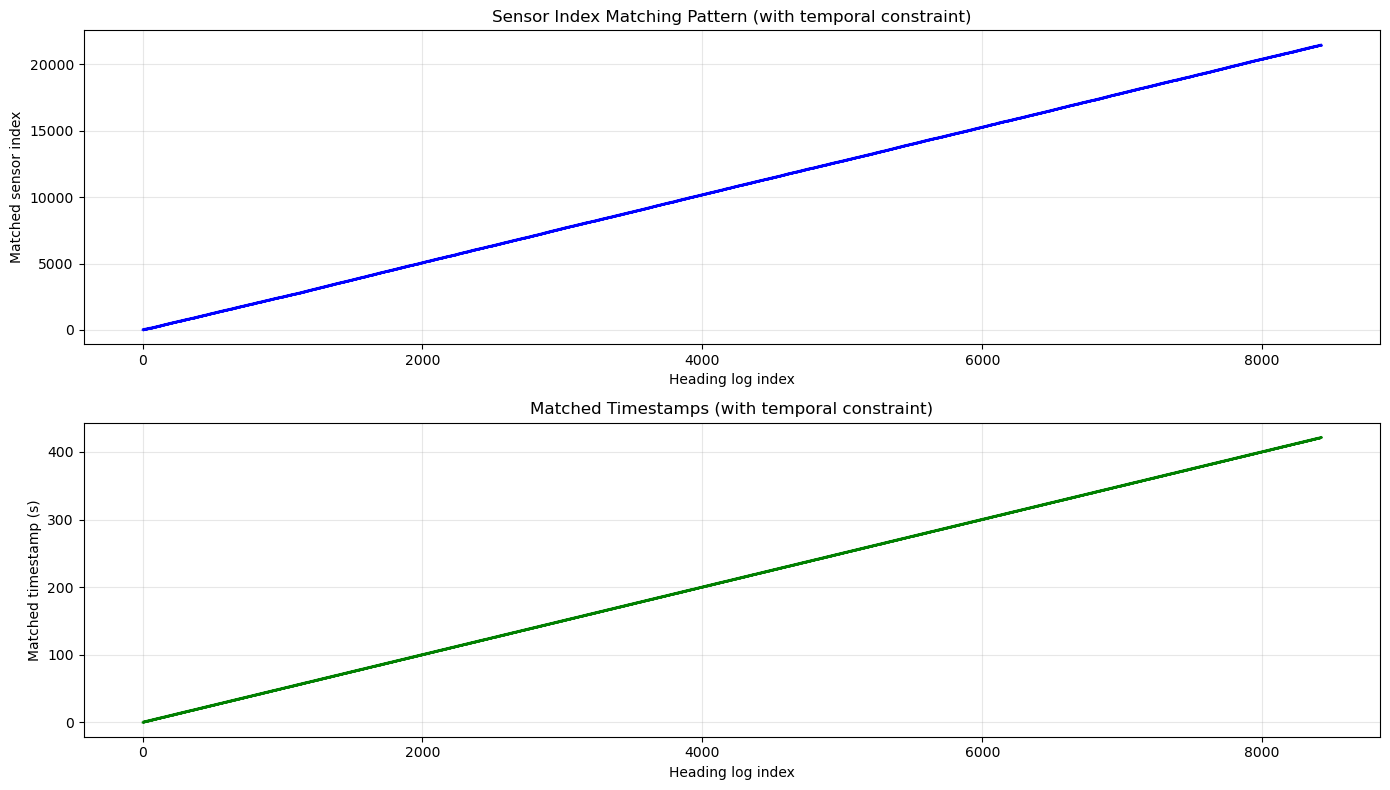

In [8]:
import numpy as np
import re
import json
import transforms3d.euler as euler
import matplotlib.pyplot as plt

def parse_sensor_log(sensor_log_file):
    """Parse sensor log to extract timestamps and quaternions"""
    sensor_pattern = r'\[INFO\] \[(\d+\.\d+)\] \[turtle_sensors_node\]: (.+)'
    
    timestamps = []
    quaternions = []
    
    with open(sensor_log_file, 'r') as f:
        for line in f:
            match = re.search(sensor_pattern, line)
            if match:
                timestamp = float(match.group(1))
                data_str = match.group(2)
                
                if data_str.strip().startswith('{') and data_str.strip().endswith('}'):
                    try:
                        sensor_json = json.loads(data_str)
                        quat = sensor_json.get('Quat', None)
                        if quat and len(quat) == 4:
                            timestamps.append(timestamp)
                            quaternions.append(quat)
                    except json.JSONDecodeError:
                        continue
    
    return np.array(timestamps), np.array(quaternions)

def parse_heading_log(heading_log_file):
    """Parse heading log to extract headings"""
    heading_pattern = r'heading: ([-\d.]+)'
    
    headings = []
    
    with open(heading_log_file, 'r') as f:
        for line in f:
            match = re.search(heading_pattern, line)
            if match:
                heading = float(match.group(1))
                headings.append(heading)
    
    return np.array(headings)

def quaternion_to_heading(quat, euler_convention='szyx'):
    """Convert quaternion to heading (yaw angle)"""
    q_eul = euler.quat2euler(quat, euler_convention)
    heading = q_eul[0]
    return heading

def match_headings_with_temporal_constraint(sensor_log_file, heading_log_file, 
                                           euler_convention='szyx', 
                                           tolerance=0.01,
                                           time_window=1.0):
    """
    Match headings with temporal constraint to prevent jumping around in time
    
    Args:
        time_window: Only look ±time_window seconds from expected position
    """
    
    timestamps, quaternions = parse_sensor_log(sensor_log_file)
    headings = parse_heading_log(heading_log_file)
    
    sensor_headings = np.array([quaternion_to_heading(q, euler_convention) for q in quaternions])
    
    print(f"Sensor time range: {timestamps[0]:.3f} to {timestamps[-1]:.3f}")
    print(f"Sensor readings: {len(timestamps)}, Heading readings: {len(headings)}")
    
    # Estimate sampling rates
    sensor_duration = timestamps[-1] - timestamps[0]
    sensor_rate = len(timestamps) / sensor_duration
    heading_rate = len(headings) / sensor_duration
    print(f"Sensor rate: {sensor_rate:.1f} Hz, Heading rate: {heading_rate:.1f} Hz")
    print(f"Time window: ±{time_window:.1f}s")
    
    matched_timestamps = []
    matched_indices = []
    last_matched_idx = 0
    
    for i, target_heading in enumerate(headings):
        # Expected time for this heading (assuming uniform rate)
        expected_time = timestamps[0] + (i / heading_rate)
        
        # Search window: use last match as anchor, allow some flexibility
        if i > 0 and last_matched_idx > 0:
            # Center search around where we expect to be based on last match
            center_idx = last_matched_idx
        else:
            # Find closest timestamp to expected time
            center_idx = np.argmin(np.abs(timestamps - expected_time))
        
        # Convert time window to index window (approximate)
        idx_window = int(time_window * sensor_rate)
        search_start = max(0, center_idx - idx_window)
        search_end = min(len(timestamps), center_idx + idx_window * 2)  # Look more forward
        
        # Get headings in search window
        search_indices = np.arange(search_start, search_end)
        
        if len(search_indices) == 0:
            matched_timestamps.append(np.nan)
            matched_indices.append(-1)
            continue
        
        # Find best heading match within window
        angle_diffs = np.arctan2(
            np.sin(sensor_headings[search_indices] - target_heading),
            np.cos(sensor_headings[search_indices] - target_heading)
        )
        diffs = np.abs(angle_diffs)
        
        best_local_idx = np.argmin(diffs)
        best_diff = diffs[best_local_idx]
        best_idx = search_indices[best_local_idx]
        
        if best_diff < tolerance:
            matched_timestamps.append(timestamps[best_idx])
            matched_indices.append(best_idx)
            last_matched_idx = best_idx
        else:
            matched_timestamps.append(np.nan)
            matched_indices.append(-1)
    
    matched_timestamps = np.array(matched_timestamps)
    matched_indices = np.array(matched_indices)
    
    # Check monotonicity
    valid_mask = matched_indices >= 0
    valid_indices = matched_indices[valid_mask]
    non_monotonic = np.sum(np.diff(valid_indices) < 0)
    
    print(f"\nMatching stats:")
    print(f"  Total matches: {np.sum(valid_mask)}/{len(headings)}")
    print(f"  Non-monotonic transitions: {non_monotonic}")
    
    # Convert to elapsed time
    start_time = timestamps[0]
    matched_timestamps = matched_timestamps - start_time
    
    return matched_timestamps, matched_indices

def save_timestamps(timestamps, output_file):
    """Save timestamps to file"""
    np.savetxt(output_file, timestamps, fmt='%.6f', header='Elapsed_Time_Seconds')
    print(f"\nSaved timestamps to {output_file}")
    
    # Print statistics
    valid_timestamps = timestamps[~np.isnan(timestamps)]
    if len(valid_timestamps) > 0:
        print(f"Valid timestamps: {len(valid_timestamps)}/{len(timestamps)}")
        print(f"Timestamp range: {np.min(valid_timestamps):.2f}s to {np.max(valid_timestamps):.2f}s")
        print(f"Duration: {np.max(valid_timestamps) - np.min(valid_timestamps):.2f}s")


# Run the matching
sensor_log = "TurtleSensors.log"
heading_log = "untethered_planning_node.log"
output_file = "matched_timestamps_temporal.txt"

timestamps, indices = match_headings_with_temporal_constraint(
    sensor_log,
    heading_log,
    euler_convention='szyx',
    tolerance=0.01,
    time_window=1.0  # Only look ±1 second from expected position
)

save_timestamps(timestamps, output_file)

# Plot to verify
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(indices, 'b.-', alpha=0.6, markersize=1)
ax1.set_xlabel('Heading log index')
ax1.set_ylabel('Matched sensor index')
ax1.set_title('Sensor Index Matching Pattern (with temporal constraint)')
ax1.grid(True, alpha=0.3)

valid_mask = ~np.isnan(timestamps)
ax2.plot(np.where(valid_mask)[0], timestamps[valid_mask], 'g.-', alpha=0.6, markersize=1)
ax2.set_xlabel('Heading log index')
ax2.set_ylabel('Matched timestamp (s)')
ax2.set_title('Matched Timestamps (with temporal constraint)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matching_temporal_constraint.png', dpi=150)
print("\nPlot saved to 'matching_temporal_constraint.png'")
plt.show()